In [1]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/TON_IoT"
PROC_DIR = f"{BASE_DIR}/processed"

Mounted at /content/drive


In [2]:
import pandas as pd
import os

train_path = f"{PROC_DIR}/toniot_network_train_70_30.parquet"
test_path  = f"{PROC_DIR}/toniot_network_test_70_30.parquet"

print(os.path.isfile(train_path), os.path.isfile(test_path))

train_df = pd.read_parquet(train_path)
test_df  = pd.read_parquet(test_path)

# Séparer X / y
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]

X_test  = test_df.drop(columns=["label"])
y_test  = test_df["label"]

X_train.shape, X_test.shape

True True


((147730, 53), (63313, 53))

In [3]:
print("train_df colonnes :", len(train_df.columns))
print(train_df.columns)

print("X_train colonnes :", len(X_train.columns))
print(X_train.columns)

train_df colonnes : 54
Index(['src_port', 'dst_port', 'duration', 'src_bytes', 'dst_bytes',
       'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'proto_icmp', 'proto_tcp',
       'proto_udp', 'service_-', 'service_dce_rpc', 'service_dns',
       'service_ftp', 'service_gssapi', 'service_http', 'service_smb',
       'service_smb;gssapi', 'service_ssl', 'conn_state_OTH', 'conn_state_REJ',
       'conn_state_RSTO', 'conn_state_RSTOS0', 'conn_state_RSTR',
       'conn_state_RSTRH', 'conn_state_S0', 'conn_state_S1', 'conn_state_S2',
       'conn_state_S3', 'conn_state_SF', 'conn_state_SH', 'conn_state_SHR',
       'dns_AA_-', 'dns_AA_F', 'dns_AA_T', 'dns_RD_-', 'dns_RD_F', 'dns_RD_T',
       'dns_RA_-', 'dns_RA_F', 'dns_RA_T', 'dns_rejected_-', 'dns_rejected_F',
       'dns_rejected_T', 'label'],
      dtype='object')
X_train colonnes : 53
In

In [4]:
# X_train, y_train, X_test, y_test existent déjà

# Normal / attaque
X_train_normal = X_train[y_train == 0]
X_test_normal  = X_test[y_test == 0]
X_test_attack  = X_test[y_test == 1]

X_train_normal.shape, X_test_normal.shape, X_test_attack.shape

((35000, 53), (15000, 53), (48313, 53))

In [5]:
# Liste des features (colonnes)
features = list(X_train.columns)
print("Nombre de features :", len(features))
for i, f in enumerate(features, start=1):
    print(f"{i:02d} - {f}")

Nombre de features : 53
01 - src_port
02 - dst_port
03 - duration
04 - src_bytes
05 - dst_bytes
06 - missed_bytes
07 - src_pkts
08 - src_ip_bytes
09 - dst_pkts
10 - dst_ip_bytes
11 - dns_qclass
12 - dns_qtype
13 - dns_rcode
14 - http_request_body_len
15 - http_response_body_len
16 - http_status_code
17 - proto_icmp
18 - proto_tcp
19 - proto_udp
20 - service_-
21 - service_dce_rpc
22 - service_dns
23 - service_ftp
24 - service_gssapi
25 - service_http
26 - service_smb
27 - service_smb;gssapi
28 - service_ssl
29 - conn_state_OTH
30 - conn_state_REJ
31 - conn_state_RSTO
32 - conn_state_RSTOS0
33 - conn_state_RSTR
34 - conn_state_RSTRH
35 - conn_state_S0
36 - conn_state_S1
37 - conn_state_S2
38 - conn_state_S3
39 - conn_state_SF
40 - conn_state_SH
41 - conn_state_SHR
42 - dns_AA_-
43 - dns_AA_F
44 - dns_AA_T
45 - dns_RD_-
46 - dns_RD_F
47 - dns_RD_T
48 - dns_RA_-
49 - dns_RA_F
50 - dns_RA_T
51 - dns_rejected_-
52 - dns_rejected_F
53 - dns_rejected_T


In [6]:
features = X_train.columns
print("Nombre de features :", len(features))
print("-"*60)
for i, col in enumerate(features, start=1):
    dtype = X_train[col].dtype
    missing = X_train[col].isna().sum()
    print(f"{i:02d} - {col} | dtype={dtype} | missing={missing}")

Nombre de features : 53
------------------------------------------------------------
01 - src_port | dtype=int64 | missing=0
02 - dst_port | dtype=int64 | missing=0
03 - duration | dtype=float64 | missing=0
04 - src_bytes | dtype=int64 | missing=0
05 - dst_bytes | dtype=int64 | missing=0
06 - missed_bytes | dtype=int64 | missing=0
07 - src_pkts | dtype=int64 | missing=0
08 - src_ip_bytes | dtype=int64 | missing=0
09 - dst_pkts | dtype=int64 | missing=0
10 - dst_ip_bytes | dtype=int64 | missing=0
11 - dns_qclass | dtype=int64 | missing=0
12 - dns_qtype | dtype=int64 | missing=0
13 - dns_rcode | dtype=int64 | missing=0
14 - http_request_body_len | dtype=int64 | missing=0
15 - http_response_body_len | dtype=int64 | missing=0
16 - http_status_code | dtype=int64 | missing=0
17 - proto_icmp | dtype=bool | missing=0
18 - proto_tcp | dtype=bool | missing=0
19 - proto_udp | dtype=bool | missing=0
20 - service_- | dtype=bool | missing=0
21 - service_dce_rpc | dtype=bool | missing=0
22 - service_

In [7]:
import numpy as np
import pandas as pd
# vérifier les classes
print("Classes y_train:", np.unique(y_train))
print("Distribution y_train:\n", pd.Series(y_train).value_counts())

Classes y_train: [0 1]
Distribution y_train:
 label
1    112730
0     35000
Name: count, dtype: int64


In [8]:
import numpy as np
import pandas as pd

def entropy_from_counts(counts):
    probs = counts / counts.sum()
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

def entropy_series(x: pd.Series):
    counts = x.value_counts(dropna=False).to_numpy()
    return entropy_from_counts(counts)

In [9]:
#Entropie conditionnelle H(X|y)
def conditional_entropy(x: pd.Series, y: pd.Series):
    h = 0.0
    for cls in y.unique():
        x_sub = x[y == cls]
        p = len(x_sub) / len(x)
        h += p * entropy_series(x_sub)
    return h

In [10]:
from pandas.api.types import is_bool_dtype, is_numeric_dtype

def discretize_feature(x: pd.Series, n_bins=20):
    if is_bool_dtype(x):
        return x.astype(int)
    if is_numeric_dtype(x):
        return pd.qcut(x, q=n_bins, duplicates='drop')
    return x.astype(str)

In [11]:
y_series = pd.Series(y_train).reset_index(drop=True)

mi_results = []

for feature in X_train.columns:
    x = X_train[feature].reset_index(drop=True)
    x_disc = discretize_feature(x)

    Hx = entropy_series(x_disc)
    Hx_y = conditional_entropy(x_disc, y_series)
    MI = Hx - Hx_y

    mi_results.append((feature, Hx, Hx_y, MI))

mi_df = pd.DataFrame(
    mi_results,
    columns=["Feature", "H(X)", "H(X|y)", "MI"]
).sort_values("MI", ascending=False)

mi_df.head(10)

,Feature,H(X),H(X|y),MI
1,dst_port,2.976943,2.585573,0.391370
17,proto_tcp,0.721711,0.489029,0.232683
7,src_ip_bytes,3.765036,3.532527,0.232509
18,proto_udp,0.719062,0.486640,0.232422
51,dns_rejected_F,0.574131,0.364306,0.209825
21,service_dns,0.693752,0.492437,0.201315
48,dns_RA_F,0.596824,0.421473,0.175351
6,src_pkts,2.029375,1.863934,0.165441
34,conn_state_S0,0.803851,0.646681,0.157170
47,dns_RA_-,0.647080,0.495352,0.151728


In [12]:
import pandas as pd
pd.set_option('display.max_rows', None)
mi_df

,Feature,H(X),H(X|y),MI
1,dst_port,2.976943,2.585573,0.391370
17,proto_tcp,0.721711,0.489029,0.232683
7,src_ip_bytes,3.765036,3.532527,0.232509
18,proto_udp,0.719062,0.486640,0.232422
51,dns_rejected_F,0.574131,0.364306,0.209825
21,service_dns,0.693752,0.492437,0.201315
48,dns_RA_F,0.596824,0.421473,0.175351
6,src_pkts,2.029375,1.863934,0.165441
34,conn_state_S0,0.803851,0.646681,0.157170
47,dns_RA_-,0.647080,0.495352,0.151728


In [13]:
# choisir k
k = 10
# récupérer les k meilleures features
top_k_features = mi_df.head(k)["Feature"].tolist()

print(f"Nombre de features sélectionnées : {len(top_k_features)}")
print("Top-k features :")
for f in top_k_features:
    print(" -", f)

Nombre de features sélectionnées : 10
Top-k features :
 - dst_port
 - proto_tcp
 - src_ip_bytes
 - proto_udp
 - dns_rejected_F
 - service_dns
 - dns_RA_F
 - src_pkts
 - conn_state_S0
 - dns_RA_-


In [14]:
# Appliquer la sélection à X_train et X_test
X_train_topk = X_train[top_k_features]
X_test_topk  = X_test[top_k_features]

print("Shape X_train_topk :", X_train_topk.shape)
print("Shape X_test_topk  :", X_test_topk.shape)

Shape X_train_topk : (147730, 10)
Shape X_test_topk  : (63313, 10)


In [15]:
assert list(X_train_topk.columns) == list(X_test_topk.columns)
print("Meme ordre de features dans train et test")

Meme ordre de features dans train et test


In [17]:
# Séparation du test
X_test_normal_topk = X_test_topk[y_test == 0]
X_test_attack_topk = X_test_topk[y_test == 1]

print("Test normal shape :", X_test_normal_topk.shape)
print("Test attack shape :", X_test_attack_topk.shape)

Test normal shape : (15000, 10)
Test attack shape : (48313, 10)


In [18]:
X_train_normal_topk = X_train_topk[y_train == 0]
X_train_attack_topk = X_train_topk[y_train == 1]

print("Train normal shape :", X_train_normal_topk.shape)
print("Train attack shape :", X_train_attack_topk.shape)

Train normal shape : (35000, 10)
Train attack shape : (112730, 10)


In [19]:
#FIT scaler uniquement sur le train normal
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_normal_scaled_topk = scaler.fit_transform(X_train_normal_topk)

In [20]:
X_train_scaled_topk = scaler.transform(X_train_topk)
X_test_scaled_topk = scaler.transform(X_test_topk)
X_test_normal_scaled_topk = scaler.transform(X_test_normal_topk)
X_test_attack_scaled_topk = scaler.transform(X_test_attack_topk)

In [21]:
print("Train normal scaled :", X_train_normal_scaled_topk.shape)
print("Train all scaled    :", X_train_scaled_topk.shape)
print("Test normal scaled  :", X_test_normal_scaled_topk.shape)
print("Test attack scaled  :", X_test_attack_scaled_topk.shape)

Train normal scaled : (35000, 10)
Train all scaled    : (147730, 10)
Test normal scaled  : (15000, 10)
Test attack scaled  : (48313, 10)


In [22]:
!pip install keras-tuner --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.2 MB/s eta 0:00:00


In [23]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model
import keras_tuner as kt

input_dim = X_train_normal_scaled_topk.shape[1]

def build_asae(hp):

    inputs = layers.Input(shape=(input_dim,))

    # encoder
    x = inputs

    # nombre de couches encodeur (1 à 3)
    for i in range(hp.Int("enc_layers", 1, 3)):
        units = hp.Int(f"enc_units_{i}", min_value=16, max_value=128, step=16)
        x = layers.Dense(
            units,
            activation="relu",
            activity_regularizer=regularizers.l1(
                hp.Choice("l1_reg", [1e-4, 5e-5, 1e-5, 1e-6])
            )
        )(x)

    # latent space
    latent_dim = hp.Int("latent_dim", min_value=8, max_value=32, step=4)
    latent = layers.Dense(latent_dim, activation="relu", name="latent")(x)

    # decoder
    x = latent
    for i in range(hp.Int("dec_layers", 1, 3)):
        units = hp.Int(f"dec_units_{i}", min_value=16, max_value=128, step=16)
        x = layers.Dense(units, activation="relu")(x)

    outputs = layers.Dense(input_dim, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    # compiler avec un LR variable
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4, 1e-4])

    model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                  loss="mse")

    return model

In [24]:
tuner = kt.Hyperband(
    build_asae,
    objective="val_loss",
    max_epochs=30,
    factor=3,
    directory="asae_tuner",
    project_name="toniot_asae"
)

In [25]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [26]:
tuner.search(
    X_train_normal_scaled_topk,
    X_train_normal_scaled_topk,
    validation_split=0.1,
    epochs=30,
    callbacks=[early_stop],
    batch_size=64   # batch size initial
)

Trial 90 Complete [00h 00m 48s]
val_loss: 0.44001445174217224

Best val_loss So Far: 0.43733346462249756
Total elapsed time: 00h 25m 06s


In [27]:
tuner.results_summary()

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]

for name, value in best_hp.values.items():
    print(f"{name}: {value}")

Results summary
Results in asae_tuner/toniot_asae
Showing 10 best trials
Objective(name="val_loss", direction="min")

Trial 0072 summary
Hyperparameters:
enc_layers: 3
enc_units_0: 32
l1_reg: 1e-06
latent_dim: 20
dec_layers: 1
dec_units_0: 48
learning_rate: 0.0005
enc_units_1: 128
enc_units_2: 32
dec_units_1: 32
dec_units_2: 96
tuner/epochs: 30
tuner/initial_epoch: 10
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0071
Score: 0.43733346462249756

Trial 0082 summary
Hyperparameters:
enc_layers: 1
enc_units_0: 32
l1_reg: 1e-06
latent_dim: 28
dec_layers: 1
dec_units_0: 96
learning_rate: 0.001
enc_units_1: 80
enc_units_2: 80
dec_units_1: 64
dec_units_2: 112
tuner/epochs: 30
tuner/initial_epoch: 10
tuner/bracket: 1
tuner/round: 1
tuner/trial_id: 0074
Score: 0.4374273419380188

Trial 0050 summary
Hyperparameters:
enc_layers: 1
enc_units_0: 80
l1_reg: 1e-05
latent_dim: 28
dec_layers: 1
dec_units_0: 80
learning_rate: 0.001
enc_units_1: 48
enc_units_2: 48
dec_units_1: 16
dec_units_2: 128
tuner

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

# Reconstruire le meilleur ASAE
best_asae = tuner.hypermodel.build(best_hp)

early_stop_final = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = best_asae.fit(
    X_train_normal_scaled_topk,
    X_train_normal_scaled_topk,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    callbacks=[early_stop_final],
    verbose=1
)

Epoch 1/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 0.7493 - val_loss: 0.4506
Epoch 2/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6126 - val_loss: 0.4472
Epoch 3/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6097 - val_loss: 0.4456
Epoch 4/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6081 - val_loss: 0.4440
Epoch 5/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6067 - val_loss: 0.4427
Epoch 6/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6057 - val_loss: 0.4420
Epoch 7/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6051 - val_loss: 0.4416
Epoch 8/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6047 - val_loss: 0.4412
Epoch 9/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6043 - val_loss: 0.4409
Epoch 10/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6041 - val_loss: 0.4407
Epoch 11/100
493/493 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6038 - val_loss: 0.4405
Epoch 12/100
493/493 ━━━━━━━━━━━━━━━━━━━━

In [29]:
import numpy as np
from sklearn.metrics import precision_recall_curve, accuracy_score, precision_score, recall_score, \
                            f1_score, roc_auc_score, average_precision_score, confusion_matrix

In [30]:
# Reconstruction sur tout le test (normal + attack)
recon_all = best_asae.predict(X_test_scaled_topk, batch_size=256)
mse_all   = np.mean((X_test_scaled_topk - recon_all)**2, axis=1)
y_true    = y_test.values  # ou .ravel()

248/248 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step


In [31]:
# Seuil data-driven via courbe PR
precision, recall, thresholds = precision_recall_curve(y_true, mse_all)
diff = np.abs(precision - recall)
idx  = np.argmin(diff)
optimal_threshold = thresholds[idx]
print("Seuil optimal :", optimal_threshold)

Seuil optimal : 0.5270527995647527


In [32]:
# Prédictions binaires
y_pred = (mse_all >= optimal_threshold).astype(int)

In [33]:
# Métriques
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)
roc  = roc_auc_score(y_true, mse_all)
pr   = average_precision_score(y_true, mse_all)
cm   = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

acc, prec, rec, f1, roc, pr, fpr, fnr, cm

(0.9017579328100074,
 0.9356280918179372,
 0.9356280918179372,
 0.9356280918179372,
 np.float64(0.8714983869075955),
 np.float64(0.8939406817059861),
 np.float64(0.20733333333333334),
 np.float64(0.0643719081820628),
 array([[11890,  3110],
        [ 3110, 45203]]))

In [34]:
encoder = tf.keras.Model(
    inputs=best_asae.input,
    outputs=best_asae.get_layer("latent").output
)

In [35]:
Z_train_normal = encoder.predict(X_train_normal_scaled_topk, batch_size=256)
Z_test = encoder.predict(X_test_scaled_topk, batch_size=256)

print("Z_train_normal shape:", Z_train_normal.shape)
print("Z_test shape:", Z_test.shape)

137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Z_train_normal shape: (35000, 20)
Z_test shape: (63313, 20)


In [36]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination="auto",
    novelty=True,
    metric="minkowski"
)

lof.fit(Z_train_normal)

LocalOutlierFactor(n_neighbors=35, novelty=True)

In [37]:
lof_pred = lof.predict(Z_test)   # +1 normal / -1 anomalie
lof_pred = (lof_pred == -1).astype(int)

In [38]:
# verifier combien LOF détecte d’anomalies
print("Nb anomalies détectées par LOF :", lof_pred.sum())
print("Nb total test :", len(lof_pred))
print("Taux anomalies LOF :", lof_pred.mean())

Nb anomalies détectées par LOF : 38377
Nb total test : 63313
Taux anomalies LOF : 0.6061472367444285


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_true = y_test.values if hasattr(y_test, "values") else y_test

acc_lof = accuracy_score(y_true, lof_pred)
prec_lof = precision_score(y_true, lof_pred)
rec_lof = recall_score(y_true, lof_pred)
f1_lof = f1_score(y_true, lof_pred)
cm_lof = confusion_matrix(y_true, lof_pred)

print("LOF seul")
print("Accuracy:", acc_lof)
print("Precision:", prec_lof)
print("Recall:", rec_lof)
print("F1:", f1_lof)
print("Confusion matrix:\n", cm_lof)

LOF seul
Accuracy: 0.8296400423293794
Precision: 0.9889256585975975
Recall: 0.7855442634487612
F1: 0.8755796516322528
Confusion matrix:
 [[14575   425]
 [10361 37952]]


In [40]:
# fusion or
y_pred_ae = (mse_all >= optimal_threshold).astype(int)
y_pred_hybrid = ((y_pred_ae == 1) | (lof_pred == 1)).astype(int)

In [41]:
# evaluer l'hybride
def eval_model(name, yhat):
    acc = accuracy_score(y_true, yhat)
    prec = precision_score(y_true, yhat)
    rec = recall_score(y_true, yhat)
    f1 = f1_score(y_true, yhat)
    cm = confusion_matrix(y_true, yhat)
    print(f"\n {name} ")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)
    print("Confusion matrix:\n", cm)

eval_model("ASAE seul", y_pred_ae)
eval_model("LOF seul", lof_pred)
eval_model("ASAE V LOF", y_pred_hybrid)


 ASAE seul 
Accuracy: 0.9017579328100074
Precision: 0.9356280918179372
Recall: 0.9356280918179372
F1: 0.9356280918179372
Confusion matrix:
 [[11890  3110]
 [ 3110 45203]]

 LOF seul 
Accuracy: 0.8296400423293794
Precision: 0.9889256585975975
Recall: 0.7855442634487612
F1: 0.8755796516322528
Confusion matrix:
 [[14575   425]
 [10361 37952]]

 ASAE V LOF 
Accuracy: 0.9463143430259189
Precision: 0.9355001357483613
Recall: 0.9984890195185561
F1: 0.9659688222749527
Confusion matrix:
 [[11674  3326]
 [   73 48240]]


In [42]:
import os

BASE_DIR = "/content/drive/MyDrive/TON_IoT"
SAVE_DIR = os.path.join(BASE_DIR, "figures_unsupervised_v3")

os.makedirs(SAVE_DIR, exist_ok=True)

print("Figures will be saved in:", SAVE_DIR)

Figures will be saved in: /content/drive/MyDrive/TON_IoT/figures_unsupervised_v3


In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.metrics import confusion_matrix

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_and_save_confusion_matrix_blue(cm, model_name, save_dir):
    plt.figure(figsize=(5, 4))

    plt.imshow(cm, cmap=plt.cm.Blues)
    # plt.title(f"Confusion Matrix - {model_name}")
    plt.colorbar()

    classes = ["Normal", "Attack"]
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes)
    plt.yticks(tick_marks, classes)

    # Affichage des valeurs dans chaque case
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11
            )

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()

    # Sauvegarde
    filename = f"confusion_matrix_{model_name.replace(' ', '_')}.png"
    plt.savefig(os.path.join(save_dir, filename), dpi=300, bbox_inches="tight")

    # Affichage à l’écran
    plt.show()

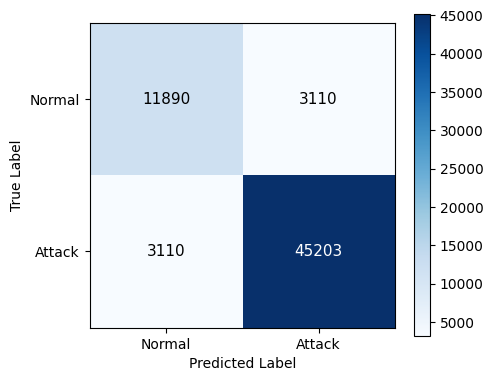

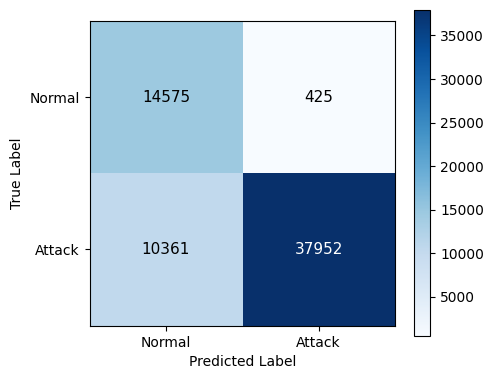

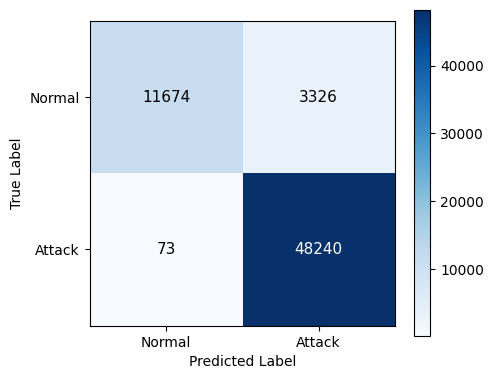

In [45]:
from sklearn.metrics import confusion_matrix

cm_ae  = confusion_matrix(y_true, y_pred_ae)
cm_lof = confusion_matrix(y_true, lof_pred)
cm_or  = confusion_matrix(y_true, y_pred_hybrid)

plot_and_save_confusion_matrix_blue(cm_ae,  "ASAE", SAVE_DIR)
plot_and_save_confusion_matrix_blue(cm_lof, "LOF", SAVE_DIR)
plot_and_save_confusion_matrix_blue(cm_or,  "ASAE V LOF", SAVE_DIR)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def collect_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred) * 100,
        "Recall": recall_score(y_true, y_pred) * 100,
        "F1-score": f1_score(y_true, y_pred) * 100
    }

results = {
    "ASAE": collect_metrics(y_true, y_pred_ae),
    "LOF": collect_metrics(y_true, lof_pred),
    "ASAE V LOF": collect_metrics(y_true, y_pred_hybrid)
}

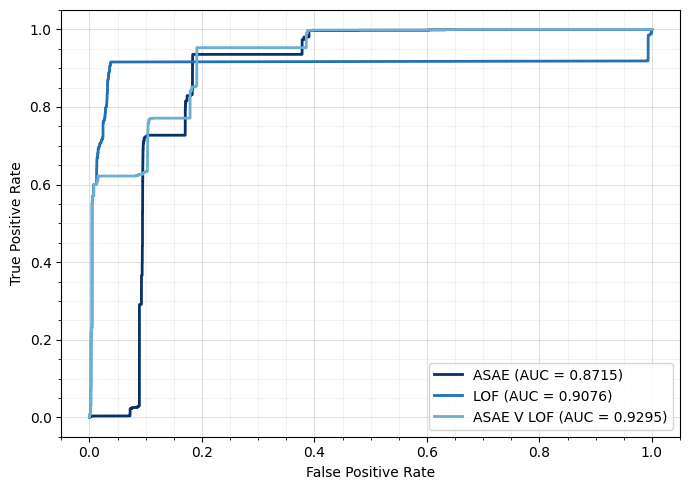

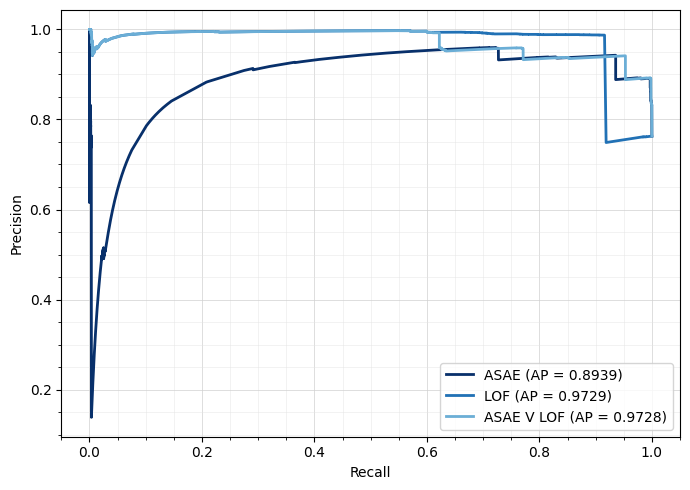

ROC-AUC
ASAE         : 0.8715
LOF          : 0.9076
ASAE V LOF  : 0.9295

PR-AUC
ASAE         : 0.8939
LOF          : 0.9729
ASAE V LOF  : 0.9728


In [52]:
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score
)

asae_score_raw = mse_all
lof_score_raw = -lof.decision_function(Z_test)

scaler_asae = MinMaxScaler()
scaler_lof = MinMaxScaler()

asae_score = scaler_asae.fit_transform(asae_score_raw.reshape(-1, 1)).ravel()
lof_score = scaler_lof.fit_transform(lof_score_raw.reshape(-1, 1)).ravel()

hybrid_score = np.maximum(asae_score, lof_score)

# y_true
y_true = y_test.values if hasattr(y_test, "values") else y_test
y_true = np.asarray(y_true).ravel()

fpr_asae, tpr_asae, _ = roc_curve(y_true, asae_score)
fpr_lof, tpr_lof, _ = roc_curve(y_true, lof_score)
fpr_hybrid, tpr_hybrid, _ = roc_curve(y_true, hybrid_score)

roc_auc_asae = auc(fpr_asae, tpr_asae)
roc_auc_lof = auc(fpr_lof, tpr_lof)
roc_auc_hybrid = auc(fpr_hybrid, tpr_hybrid)

prec_asae, rec_asae, _ = precision_recall_curve(y_true, asae_score)
prec_lof, rec_lof, _ = precision_recall_curve(y_true, lof_score)
prec_hybrid, rec_hybrid, _ = precision_recall_curve(y_true, hybrid_score)

pr_auc_asae = average_precision_score(y_true, asae_score)
pr_auc_lof = average_precision_score(y_true, lof_score)
pr_auc_hybrid = average_precision_score(y_true, hybrid_score)

os.makedirs(SAVE_DIR, exist_ok=True)



major_grid_color = "#cfcfcf"
minor_grid_color = "#e3e3e3"


color_asae = "#08306b"
color_lof = "#2171b5"
color_hybrid = "#6baed6"

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

ax.plot(fpr_asae, tpr_asae, color=color_asae, label=f"ASAE (AUC = {roc_auc_asae:.4f})", linewidth=2)
ax.plot(fpr_lof, tpr_lof, color=color_lof, label=f"LOF (AUC = {roc_auc_lof:.4f})", linewidth=2)
ax.plot(fpr_hybrid, tpr_hybrid, color=color_hybrid, label=f"ASAE V LOF (AUC = {roc_auc_hybrid:.4f})", linewidth=2)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")

ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.6, color=major_grid_color, alpha=0.8)
ax.grid(which="minor", linestyle="-", linewidth=0.4, color=minor_grid_color, alpha=0.8)

plt.tight_layout()

roc_path = os.path.join(SAVE_DIR, "roc_curve_comparison.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_alpha(0)
ax.set_facecolor("none")

ax.plot(rec_asae, prec_asae, color=color_asae, label=f"ASAE (AP = {pr_auc_asae:.4f})", linewidth=2)
ax.plot(rec_lof, prec_lof, color=color_lof, label=f"LOF (AP = {pr_auc_lof:.4f})", linewidth=2)
ax.plot(rec_hybrid, prec_hybrid, color=color_hybrid, label=f"ASAE V LOF (AP = {pr_auc_hybrid:.4f})", linewidth=2)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend(loc="lower right")

ax.minorticks_on()
ax.grid(which="major", linestyle="-", linewidth=0.6, color=major_grid_color, alpha=0.8)
ax.grid(which="minor", linestyle="-", linewidth=0.4, color=minor_grid_color, alpha=0.8)

plt.tight_layout()

pr_path = os.path.join(SAVE_DIR, "pr_curve_comparison.png")
plt.savefig(pr_path, dpi=300, bbox_inches="tight")
plt.show()

print("ROC-AUC")
print(f"ASAE         : {roc_auc_asae:.4f}")
print(f"LOF          : {roc_auc_lof:.4f}")
print(f"ASAE V LOF  : {roc_auc_hybrid:.4f}")

print("\nPR-AUC")
print(f"ASAE         : {pr_auc_asae:.4f}")
print(f"LOF          : {pr_auc_lof:.4f}")
print(f"ASAE V LOF  : {pr_auc_hybrid:.4f}")

In [53]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

def collect_metrics(y_true, y_pred, y_score):
    return {
        "Accuracy": accuracy_score(y_true, y_pred) * 100,
        "Precision": precision_score(y_true, y_pred) * 100,
        "Recall": recall_score(y_true, y_pred) * 100,
        "F1-score": f1_score(y_true, y_pred) * 100,
        "ROC-AUC": roc_auc_score(y_true, y_score) * 100,
        "PR-AUC": average_precision_score(y_true, y_score) * 100
    }

results = {
    "ASAE": collect_metrics(y_true, y_pred_ae, asae_score),
    "LOF": collect_metrics(y_true, lof_pred, lof_score),
    "ASAE V LOF": collect_metrics(y_true, y_pred_hybrid, hybrid_score)
}

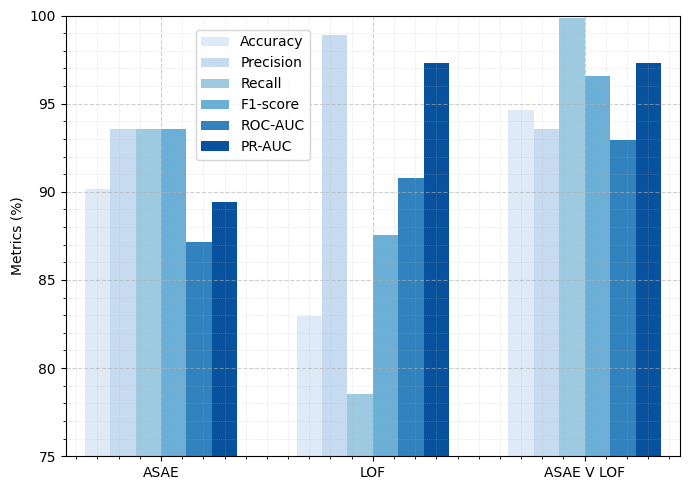

In [63]:
import numpy as np
import matplotlib.pyplot as plt
import os

models = list(results.keys())
metrics = ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]

data = np.array([[results[m][metric] for m in models] for metric in metrics])

x = np.arange(len(models))
width = 0.12

ax.set_yticks(np.arange(80, 101, 1), minor=True)
ax.minorticks_on()

ax.set_xticks(np.arange(x[0] - margin, x[-1] + margin, 0.2), minor=True)


ax.tick_params(axis='x', which='minor', length=3, width=0.8)
ax.tick_params(axis='y', which='minor', length=3, width=0.8)

ax.grid(which='major', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

fig, ax = plt.subplots(figsize=(7,5))

colors = [
    "#deebf7",
    "#c6dbef",
    "#9ecae1",
    "#6baed6",
    "#3182bd",
    "#08519c"
]

for i, metric in enumerate(metrics):
    ax.bar(
        x + (i - (len(metrics)-1)/2) * width,
        data[i],
        width,
        label=metric,
        color=colors[i]
    )

fig.patch.set_alpha(0)
ax.set_facecolor("none")
ax.set_yticks(np.arange(75, 100, 1), minor=True)
ax.set_xticks(np.arange(-0.5, len(models), 0.1), minor=True)

ax.grid(which='major', linestyle='--', linewidth=0.8, alpha=0.6)
ax.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.5)

ax.legend(loc="center", bbox_to_anchor=(0.305, 0.82), frameon=True)
margin = 0.45
ax.set_xlim(x[0] - margin, x[-1] + margin)

ax.set_ylabel("Metrics (%)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(75, 100)
plt.tight_layout()

figure_path = os.path.join(SAVE_DIR, "performance_comparison.png")
plt.savefig(figure_path, dpi=300, bbox_inches="tight", transparent=True)
plt.show()